<a href="https://colab.research.google.com/github/sascha-pst/McCombs-DSBA/blob/main/Full_Code_Notebook_EasyVisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 3.6 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
xarray 2025.7.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
xarray 2025.7.1 requires pandas>=2.2, but you have pand

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

#library to split data
from sklearn.model_selection import train_test_split

#libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
#sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

#to oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

#libraries to get metric scores
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

#to tune models
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV




# **Loading the dataset**

In [ ]:
import pandas as pd
df = pd.read_csv('EasyVisa.csv')
data = df.copy()
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


# **Overview of the Dataset**

In [ ]:
#show the top 5 rows of data
df.head()

#show the last 5 rows of data
df.tail()

#understand the shape of the dataset
df.shape

#check the data types of each column
df.dtypes

#check for duplicate values
df.duplicated().sum()

#check for missing values
df.isnull().sum()

#check for unique values in each column
df.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


## Observations
* **Entries + Columns:** There are **25480 entries** in the dataset and **11 columns** as listed in the data dictionary.
*  **Variable Types**:
  * There is 1 float variable (prevailing wage)
  * 2 integer variables (Number of Employees and Year of Establishment), and
  *  9 object variables (Case ID, Continent, Education of Employee, Has job experience, requires job training, region of employement, unit of wage, full time position and case status)
* **Data Shape**: There are more certified case studies than denied, we will need to explore in univariate and bivariate analysis to see the relationship between case status and other variables.



## Sanity checks

*   The dataset is complete, with no missing values.
*   **No_of_employees** has a minimum value of -26, which is not possible to have a negative number of employees. This indicates a potential data entry error that requires further investigation.
*   **Yr_of_estab** has a minimum value of 1800 and the mazimum is 2016, this seems reasonable
*   **prevailing_wage** has a minimum value of 2.1367 and a max value of 319210.27. The minimum value seems especially low, and needs to be considered with the unit_of_wage column for proper interpretation





# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

Perform bivariate and univariate analysis on the dataset to evaluate the relationship between the data and case status.

In [ ]:
#check the statistical summary of the data
df.describe()

#fix negative values in number of employee columns
df.loc[df['no_of_employees'] < 0].shape
df.loc[df['no_of_employees'] < 0, 'no_of_employees'] = df['no_of_employees'].abs()

#check the count of each unique categorical variable
cat_col = list(df.select_dtypes(include='object').columns)

#printing the count of each unique value
for col in cat_col:
  print(df[col].value_counts())
  print("\n")

#check the number of unique values
df.nunique()
df.drop('case_id', axis=1, inplace=True)
df.head()



case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64


continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64


education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64


has_job_experience
Y    14802
N    10678
Name: count, dtype: int64


requires_job_training
N    22525
Y     2955
Name: count, dtype: int64


region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64


unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64


full_time_position
Y    22773
N     2707
Name: count, dtype: int64


case_status
Certified   

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


# **What is the distribution of visa case statuses?**
* **Certified**: 66.8% of cases
* **Denied**: 33.2% of cases

While there are more certified cases than denied cases, it wil be crucial that we evaluate other variables against certified and denied cases to measure the relationship between what factors enable a higher certification rate.

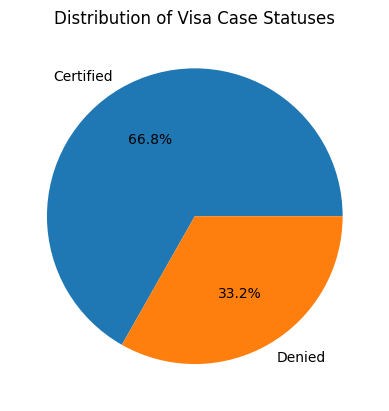

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64
Distibution of Visa Case Statuses (Counts):
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

Distribution of Visa Case Statuses (Percentages):
case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64


In [ ]:
#what is the distribution of visa case statuses (certified vs. denied)?
#calculate the value counts for the 'case_status' column
case_status_counts = df['case_status'].value_counts()

#create a pie chart of the case status distribution
plt.pie(case_status_counts, labels=case_status_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Visa Case Statuses')
plt.show()

#calcuate the percentage
case_status_percentages = df['case_status'].value_counts(normalize=True) * 100
print(case_status_percentages)

print("Distibution of Visa Case Statuses (Counts):")
print(case_status_counts)
print("\nDistribution of Visa Case Statuses (Percentages):")
print(case_status_percentages)

## **How does the education level of employees impact visa approval rates?**
*   **Higher levels of education lead to higher certification rates:** applicants with Doctorate and Master's degrees have significantly higher certification rates (87.23% and 78.63% respectively) than those with a merely a Bachelor's or High School education.

This suggests a positive correlation between higher levels of education and the likelihood of a visa application being certified and is diplayed in the charts below.

Visa Case Status Counts by Education Level:
case_status            Certified  Denied
education_of_employee                   
Bachelor's                  6367    3867
Doctorate                   1912     280
High School                 1164    2256
Master's                    7575    2059

Visa Case Status Percentages by Education Level:
case_status            Certified     Denied
education_of_employee                      
Bachelor's             62.214188  37.785812
Doctorate              87.226277  12.773723
High School            34.035088  65.964912
Master's               78.627777  21.372223


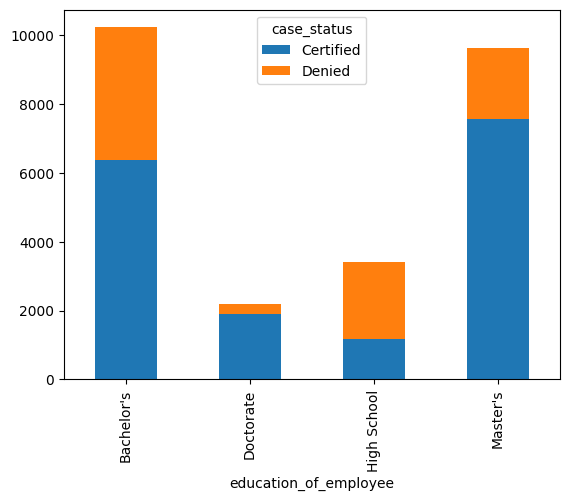

In [ ]:
#how does the education level of employees affect visa status?
#group by education level and case status, then count
education_status_counts = df.groupby(['education_of_employee', 'case_status']).size().unstack()

#create a bar chart of the education level counts
education_status_counts.plot(kind='bar', stacked=True)

#calculate percentages
education_status_percentages = education_status_counts.apply(lambda x: x / x.sum() * 100, axis=1)

print("Visa Case Status Counts by Education Level:")
print(education_status_counts)
print("\nVisa Case Status Percentages by Education Level:")
print(education_status_percentages)

## **Is there a significant difference in visa approval rates between employees with and without prior job experience?**
*   **Applicants with job experience have better chances at approval**: There appears to be a significant difference in visa approval rates between employees with and without prior job experience.
*   A significantly higher percentage of applications from individuals with job experience were Certified (74.48%), with a denial rate of 25.52%.
*   The approval rate for individuals without job experience is notably lower at 56.13% certified, with a higher denial rate of 43.87%.

Visa Approval Rates by Prior Job Experience:
case_status         Certified    Denied
has_job_experience                     
N                    0.561341  0.438659
Y                    0.744764  0.255236

Visa Approval Rates Percentages by Prior Job Experience:
case_status         Certified     Denied
has_job_experience                      
N                   56.134108  43.865892
Y                   74.476422  25.523578


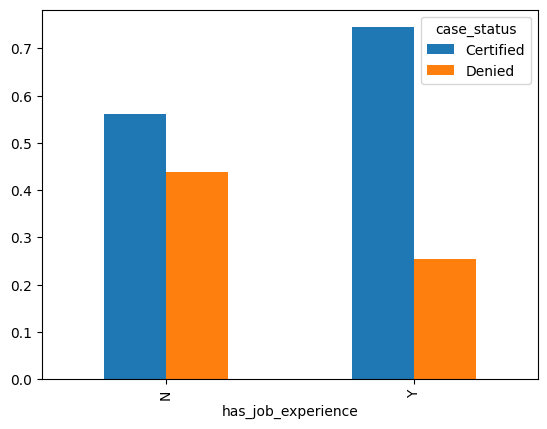

In [ ]:
# Is there a significant difference in visa approval rates between employees with and without prior job experience?
#group by prior job experience and visa approval rates
experience_approval_rates = df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).unstack()

#create bar chart of job experience
experience_approval_rates.plot(kind='bar')

#calculate percentages
experience_approval_percentages = experience_approval_rates.apply(lambda x: x / x.sum() * 100, axis=1)

print("Visa Approval Rates by Prior Job Experience:")
print(experience_approval_rates)
print("\nVisa Approval Rates Percentages by Prior Job Experience:")
print(experience_approval_percentages)

## **How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?**
* **Applicants with higher wages have a better chance at certified case status**: The mean and median prevailing wage for certified cases is higher than denied cases.
*   The mean prevailing wage for certified cases (77293.62) is higher than the denied cases (68748.68)
*   The median prevailing wage for certified cases (72486.27) is also higher than denied cases (65431.46)
*  This suggests that certified cases are associated with slightly higher prevailing wages.
*  The distribution spread of certified and denied cases are similar, the standard deviations are similar indicating a comparable spread of wages for both groups.

Both certified and denied cases show very low minimum prevailing wages. Referencing the sanity check, this is needs to consider the unit_of_wage.

Descriptive Statistics for Prevailing Wages(Certified Cases):
count     17018.000000
mean      77293.619243
std       52042.715576
min           2.136700
25%       38375.330000
50%       72486.270000
75%      108879.107500
max      318446.050000
Name: prevailing_wage, dtype: float64

Descriptive Statistics for Prevailing Wages(Denied Cases):
count      8462.000000
mean      68748.681580
std       53890.166031
min           2.956100
25%       23497.295000
50%       65431.460000
75%      105097.640000
max      319210.270000
Name: prevailing_wage, dtype: float64


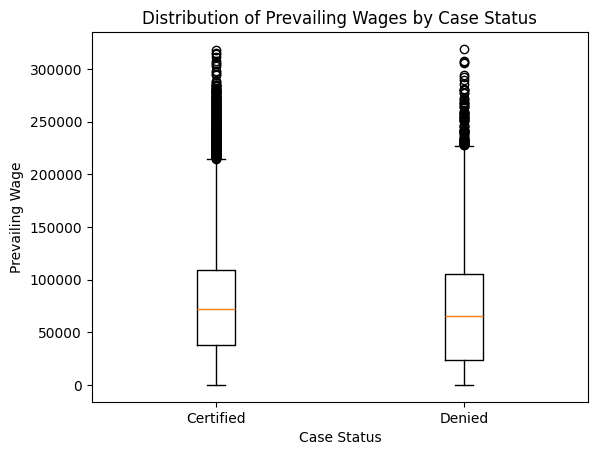

In [ ]:
# How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
#seperate prevailing wages by case status
certified_wages = df[df['case_status'] == 'Certified']['prevailing_wage']
denied_wages = df[df['case_status'] == 'Denied']['prevailing_wage']

print("Descriptive Statistics for Prevailing Wages(Certified Cases):")
print(certified_wages.describe())
print("\nDescriptive Statistics for Prevailing Wages(Denied Cases):")
print(denied_wages.describe())

#create a box plot to visualize the distribution of prevailing wages by case status
plt.boxplot([certified_wages, denied_wages], labels=['Certified', 'Denied'])
plt.title('Distribution of Prevailing Wages by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage')
plt.show()

## **Do certain regions in the US have higher visa approval rates compared to others?**
* **Applicants in certain US regions do have higher visa approval rates**: Midwest has the highest approval rate, with the highest visa certification rate at 75.53%, with the lowest denial rate of 24.47%
*   South also had a high approval rate of 70.02%
*   The Island (60.27%), Northeast(62.90%), and West (62.25%) regions are lower

Visa Case Status Counts by Region of Employment:
case_status           Certified  Denied
region_of_employment                   
Island                      226     149
Midwest                    3253    1054
Northeast                  4526    2669
South                      4913    2104
West                       4100    2486

Visa Case Status Percentages by Region of Employment:
case_status           Certified     Denied
region_of_employment                      
Island                60.266667  39.733333
Midwest               75.528210  24.471790
Northeast             62.904795  37.095205
South                 70.015676  29.984324
West                  62.253265  37.746735


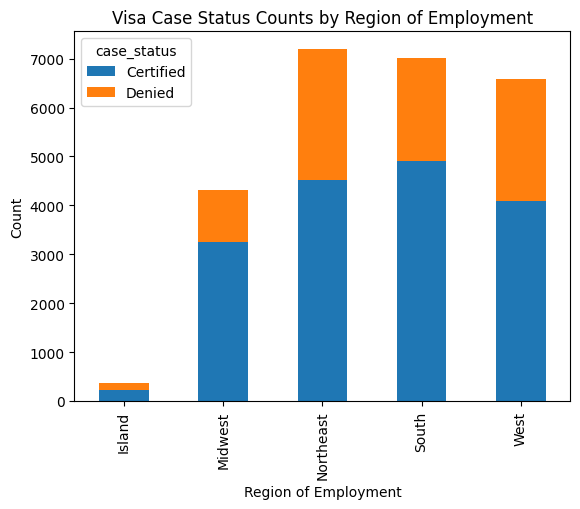

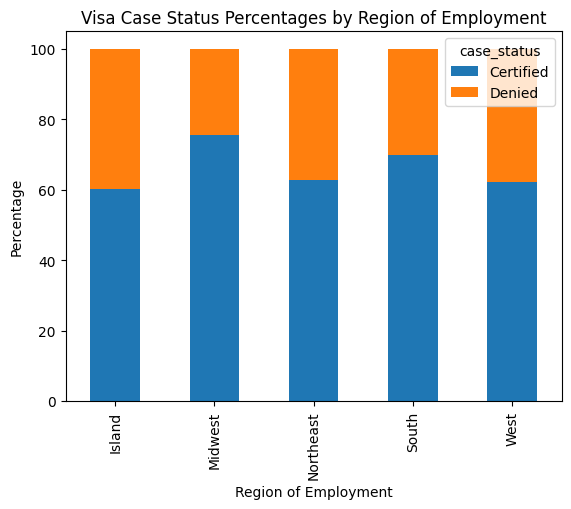

In [ ]:
#Do certain regions in the US have higher visa approval rates compared to others?
#group by region of employment and case status, then count
region_status_counts = df.groupby(['region_of_employment', 'case_status']).size().unstack()

#calculate percentages for better comparison
region_status_percentages = region_status_counts.apply(lambda x: x / x.sum() * 100, axis=1)

print("Visa Case Status Counts by Region of Employment:")
print(region_status_counts)
print("\nVisa Case Status Percentages by Region of Employment:")
print(region_status_percentages)

#create a grouped bar chart for counts
region_status_counts.plot(kind='bar', stacked=True)
plt.title('Visa Case Status Counts by Region of Employment')
plt.xlabel('Region of Employment')
plt.ylabel('Count')
plt.show()

#create a stacked bar chart for percentages
region_status_percentages.plot(kind='bar', stacked=True)
plt.title('Visa Case Status Percentages by Region of Employment')
plt.xlabel('Region of Employment')
plt.ylabel('Percentage')
plt.show()


## **How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?**

# Observations

*   The mean number of employees for certified cases (5,813) is slightly higher than denied cases (5,396). Similarly, the median number of employees for certified cases (2,150) is also slightly higher than for denied cases (2,037).
*   The standard deviations are quite large for both groups, indicating a very wide range in the number of employees, from small companies to very large corporations, for both certified and denied applications.
*    Both distributions contained high max vlues which suggest the presence of very large companies and the standard deviation being much larger than the mean points to a highly skewed distribution

## Conclusion:

While the mean and median number of employees are slightly higher for certified visa cases, the difference is not substantial. The distribution for both certified and denied cases overlap significantly, and both contain a wide range of company sizes. This suggests that while there might be a very weak positive association, the number of employees in a company alone does not appear to be a primary differentiator for visa approval or denial.

Descriptive Statistics for Number of Employees(Certified Cases):
count     17001.000000
mean       5812.843715
std       23130.397745
min          12.000000
25%        1040.000000
50%        2150.000000
75%        3578.000000
max      602069.000000
Name: no_of_employees, dtype: float64

Descriptive Statistics for Number of Employees(Denied Cases):
count      8446.000000
mean       5395.772081
std       22402.712887
min          12.000000
25%         997.000000
50%        2037.000000
75%        3389.000000
max      594472.000000
Name: no_of_employees, dtype: float64


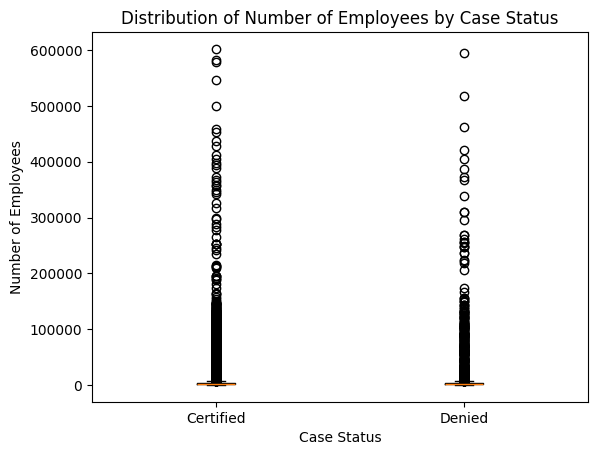

In [ ]:
#how does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#load the dataset
df = pd.read_csv('/content/EasyVisa.csv')

#filter out values where "no_of_employees" is less than or equal to 0
df_cleaned = df[df['no_of_employees'] > 0].copy()

#seperate 'no_of_employees' by case status from the cleaned data
certified_employees = df_cleaned[df_cleaned['case_status'] == 'Certified']['no_of_employees']
denied_employees = df_cleaned[df_cleaned['case_status'] == 'Denied']['no_of_employees']

print("Descriptive Statistics for Number of Employees(Certified Cases):")
print(certified_employees.describe())
print("\nDescriptive Statistics for Number of Employees(Denied Cases):")
print(denied_employees.describe())

#create a box plot to visualize the distribution of number of employees by case status
plt.boxplot([certified_employees, denied_employees], labels=['Certified', 'Denied'])
plt.title('Distribution of Number of Employees by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Number of Employees')
plt.show()




## **Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?**
*   Visa approval rates do differ across various continents of employees, Europe (79.23%), Africa (72.05%) and Asia (65.31%) have the highest certified rate.
*   South America has the lowest approval rate at 57.86% indicating a significant difference in outcomes across continents.

Visa Case Status Counts by Continent:
case_status    Certified  Denied
continent                       
Africa               397     154
Asia               11012    5849
Europe              2957     775
North America       2037    1255
Oceania              122      70
South America        493     359

Visa Case Status Percentages by Continent:
case_status    Certified     Denied
continent                          
Africa         72.050817  27.949183
Asia           65.310480  34.689520
Europe         79.233655  20.766345
North America  61.877278  38.122722
Oceania        63.541667  36.458333
South America  57.863850  42.136150

The continent with the highest approval rate is Europe with 79.23% approval rate.


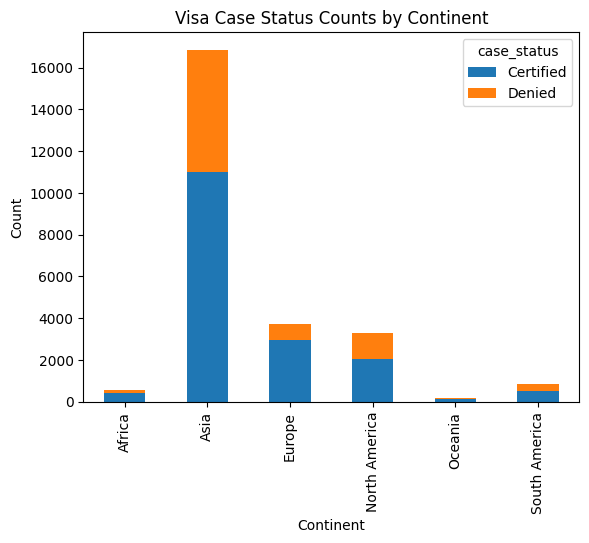

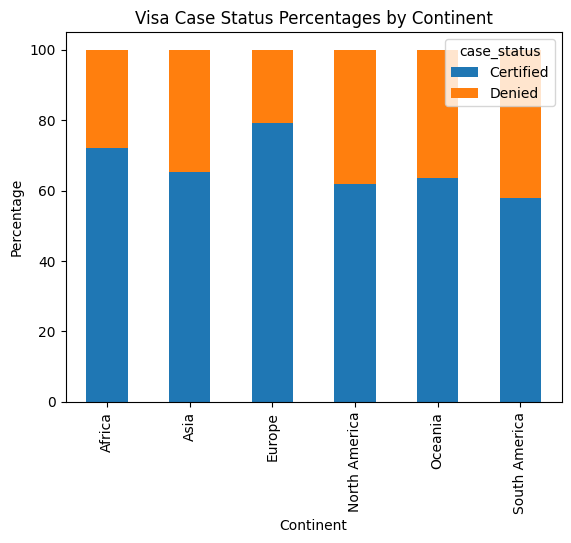

In [ ]:
# Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

#group by continent and case status, the count
continent_status_counts = df.groupby(['continent', 'case_status']).size().unstack()

#calculate percentages for better comparison
continent_status_percentages = continent_status_counts.apply(lambda x: x / x.sum() * 100, axis=1)

print("Visa Case Status Counts by Continent:")
print(continent_status_counts)
print("\nVisa Case Status Percentages by Continent:")
print(continent_status_percentages)

# Identify the continent with the highest approval rate
highest_approval_continent = continent_status_percentages['Certified'].idxmax()
highest_approval_percentage = continent_status_percentages.loc[highest_approval_continent, 'Certified']

print(f"\nThe continent with the highest approval rate is {highest_approval_continent} with {highest_approval_percentage:.2f}% approval rate.")

#create a group bar chart for counts
continent_status_counts.plot(kind='bar', stacked=True)
plt.title('Visa Case Status Counts by Continent')
plt.xlabel('Continent')
plt.ylabel('Count')
plt.show()

#create a stacked bar chart for percentages
continent_status_percentages.plot(kind='bar', stacked=True)
plt.title('Visa Case Status Percentages by Continent')
plt.xlabel('Continent')
plt.ylabel('Percentage')
plt.show()


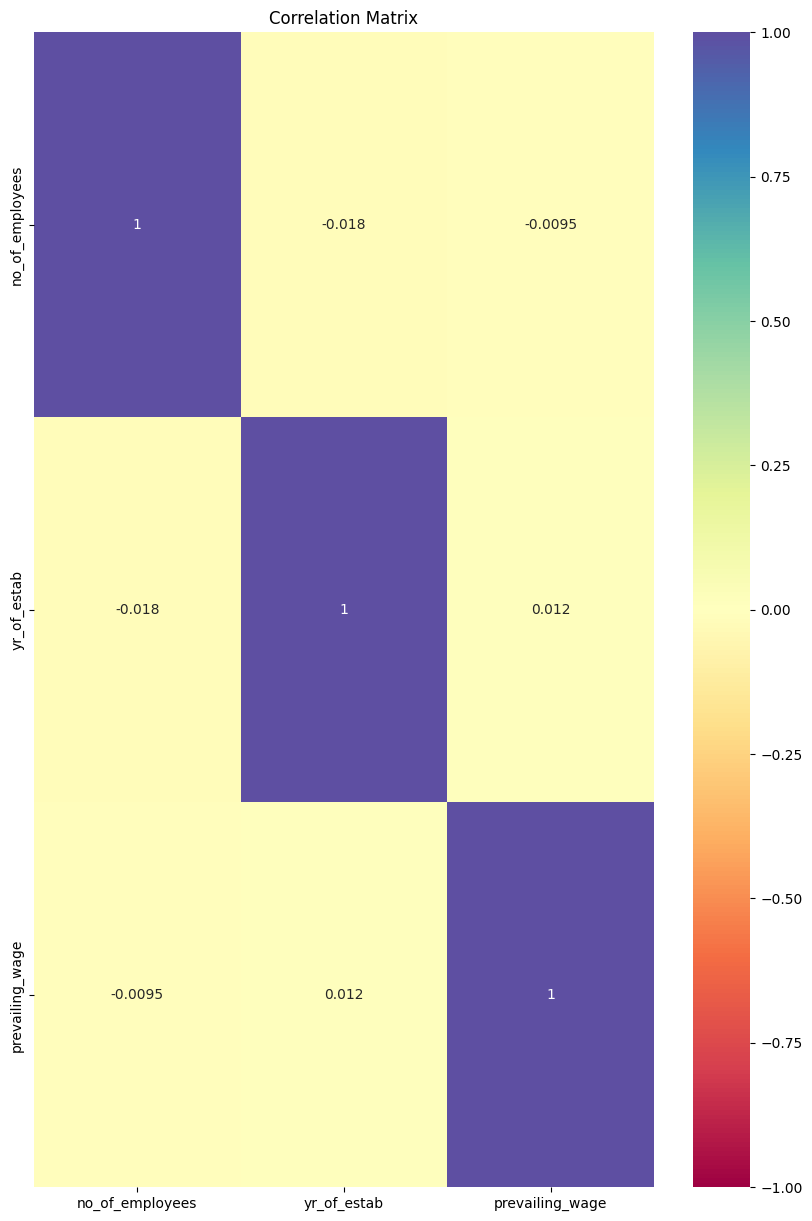

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 15))
sns.heatmap(
    data[cols_list].corr(),
    annot=True,
    cmap='Spectral',
    vmin=-1,
    vmax=1
)
plt.title('Correlation Matrix')
plt.show()


Creating functions to help with further analysis.

In [ ]:
# function to plot distrubution wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()


In [ ]:
def stacked_barplot(data, predictor, target):
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

<Axes: xlabel='region_of_employment', ylabel='prevailing_wage'>

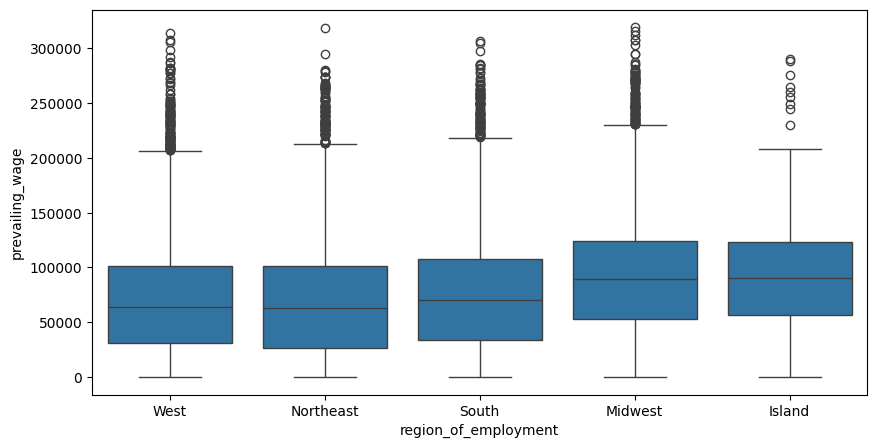

In [ ]:
#is prevailing wage similar across the regions of the US?
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")

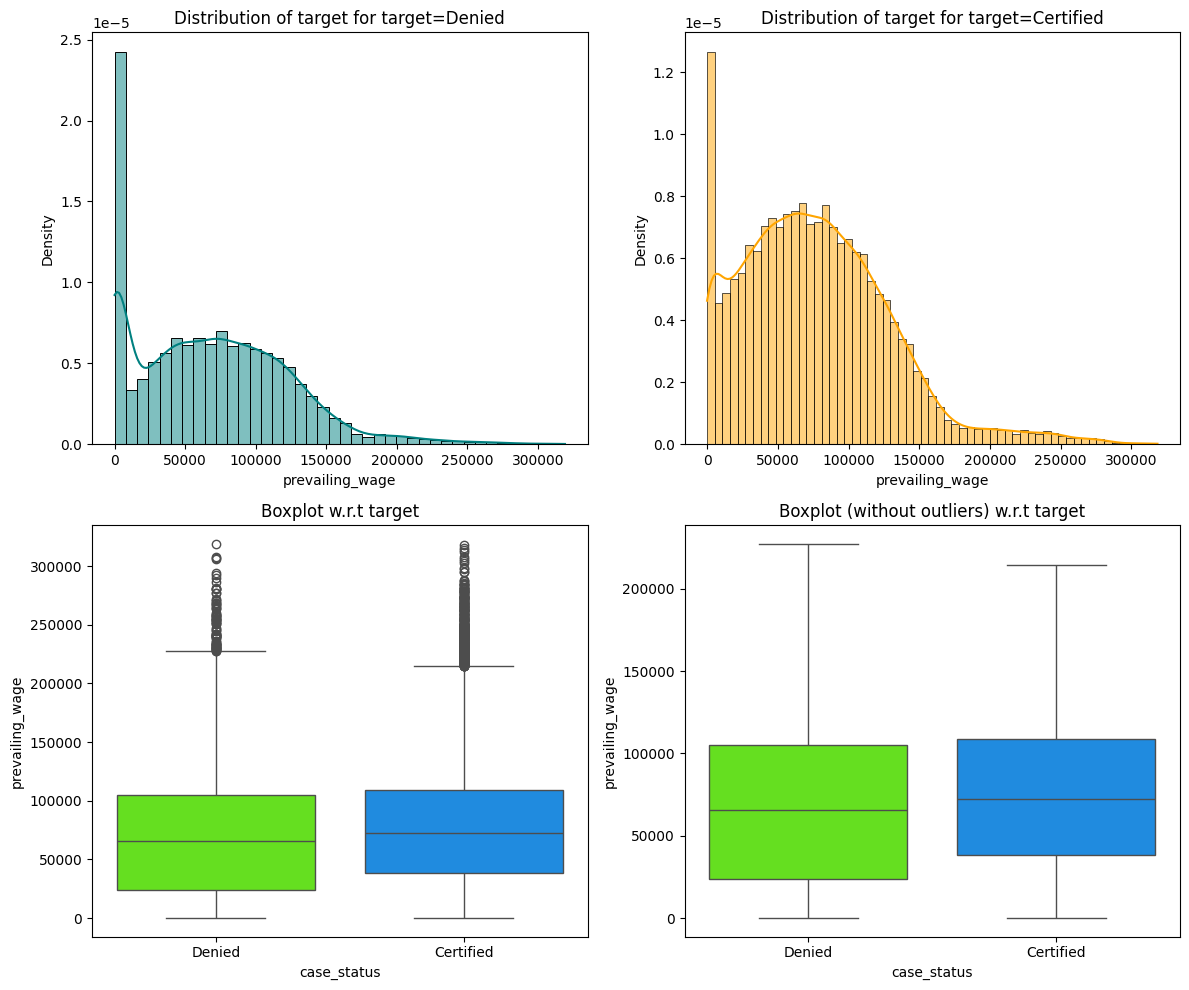

In [ ]:
#does visa status change with prevailing wage?
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

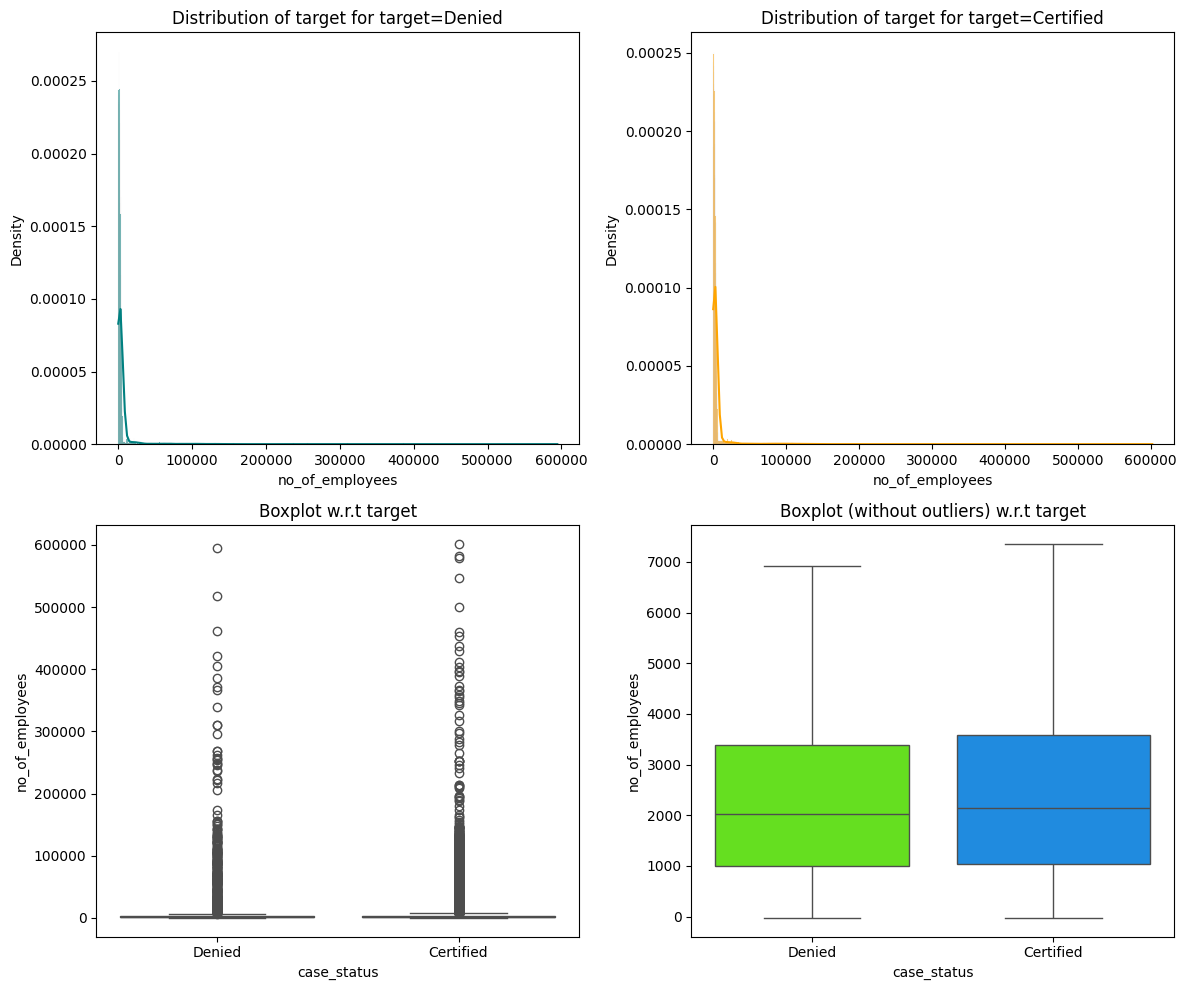

In [ ]:
#whats the relationship between number of employees and case status?
distribution_plot_wrt_target(data, "no_of_employees", "case_status")

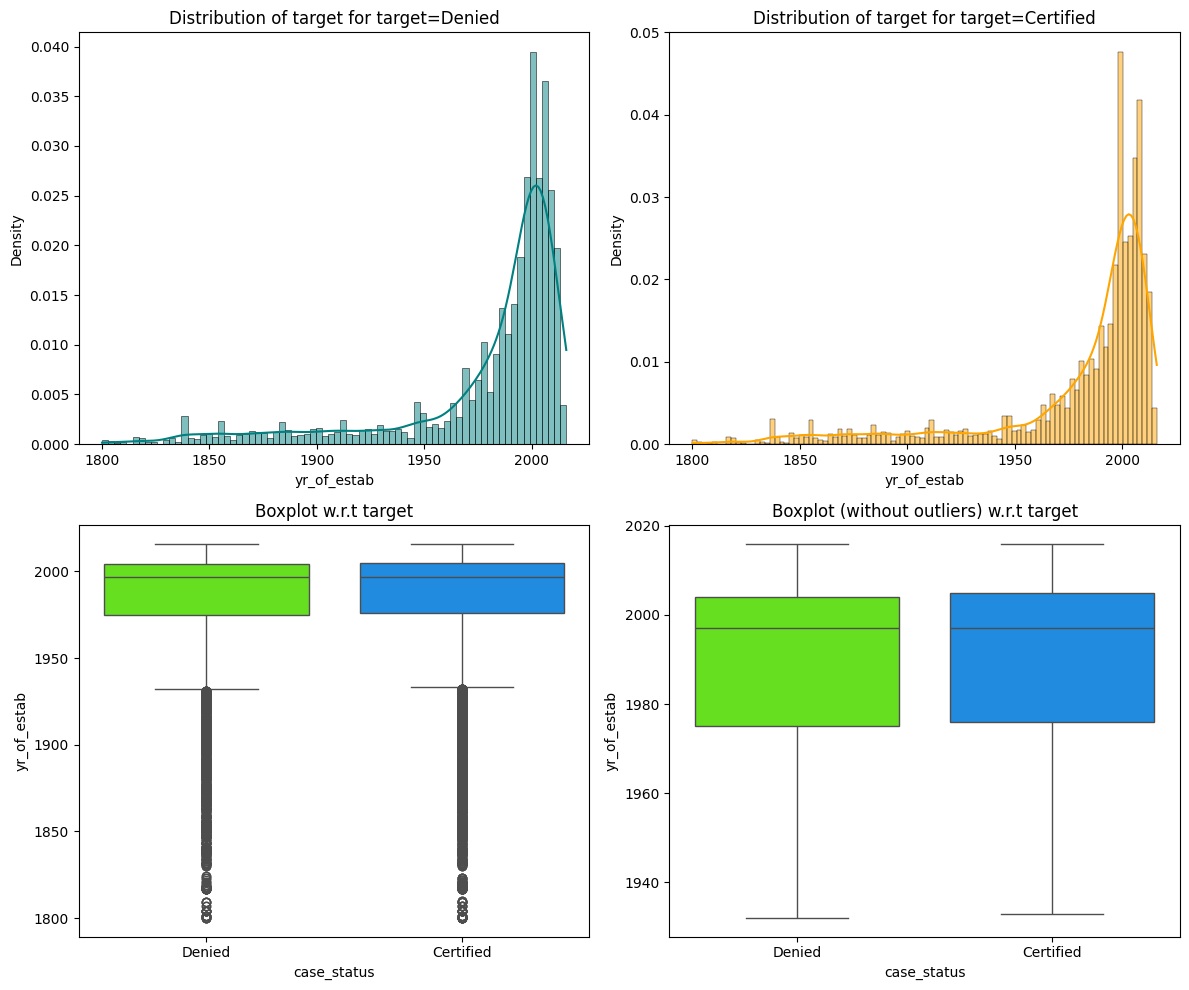

In [ ]:
#whats the realtionship between years of establishment and case status?
distribution_plot_wrt_target(data, "yr_of_estab", "case_status")

# **Data Pre-processing**

**Outlier Check**: Check for outliers in the data.

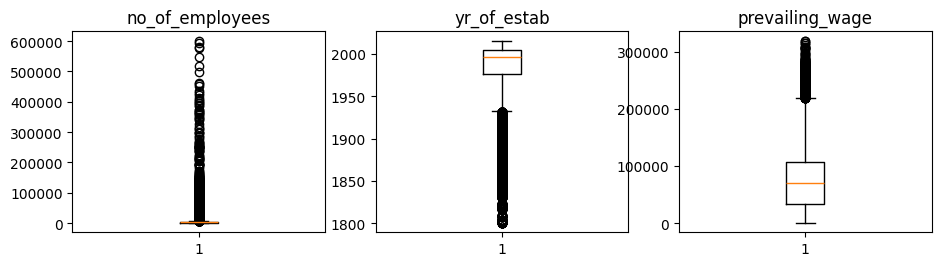

In [ ]:
#outlier check
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15,12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4,4,i+1)
    plt.boxplot(data[variable], whis=1.5)
    plt.title(variable)
plt.show()



**Data Preparation for Modeling:** Our model will predict which visa will be certified. Before building, we have to encode categorical features, split the data into training and test data, then evaluate the model built on the training data.

In [ ]:
#load the libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the data to avoid modifying the original dataframe
data_processed = data.copy()

# Pre-processing
# Convert binary categorical features to numerical
for col in ['has_job_experience', 'requires_job_training', 'full_time_position']:
    data_processed[col] = data_processed[col].map({'Y': 1, 'N': 0})

# Convert target variable to numerical
data_processed['case_status'] = data_processed['case_status'].map({'Certified': 1, 'Denied': 0})

# One-hot encode categorical features
data_processed = pd.get_dummies(data_processed, columns=['continent', 'education_of_employee', 'region_of_employment', 'unit_of_wage'], drop_first=True)

# Feature Engineering
# Create a new feature 'company_age' from 'yr_of_estab'
data_processed['company_age'] = 2023 - data_processed['yr_of_estab']
data_processed = data_processed.drop('yr_of_estab', axis=1)
data_processed = data_processed.drop('case_id', axis=1)

# Separate features (X) and target (y)
X = data_processed.drop('case_status', axis=1)
y = data_processed['case_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numerical features + ensure no data leakage
scaler = MinMaxScaler()
X_train[['no_of_employees', 'prevailing_wage', 'company_age']] = scaler.fit_transform(X_train[['no_of_employees', 'prevailing_wage', 'company_age']])
X_test[['no_of_employees', 'prevailing_wage', 'company_age']] = scaler.transform(X_test[['no_of_employees', 'prevailing_wage', 'company_age']])

print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of test set :  (7644, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64


# **Model Building**

### **Model evaluation criterion** ###
*Model can make wrong predictions as:*

Model predicts that the visa application will get certified but in reality, the visa application should get denied.
Model predicts that the visa application will not get certified but in reality, the visa application should get certified.
Which case is more important?

### **Both the cases are important as:**###

If a visa is certified when it had to be denied a wrong employee will get the job position while US citizens will miss the opportunity to work on that position.

If a visa is denied when it had to be certified the U.S. will lose a suitable human resource that can contribute to the economy.

## **How to reduce the losses?**

F1 Score can be used a the metric for evaluation of the model, greater the F1 score higher are the chances of minimizing False Negatives and False Positives.
We will use balanced class weights so that model focuses equally on both classes.
First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.

The model_performance_classification_sklearn function will be used to check the model performance of models.
The confusion_matrix_sklearn function will be used to plot the confusion matrix.

In [ ]:
#initialize libraries
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#load the data
df = pd.read_csv('/content/EasyVisa.csv')

# Pre-processing

# Drop case_id
df = df.drop('case_id', axis=1)

# Convert binary categorical features to numerical
for col in ['has_job_experience', 'requires_job_training', 'full_time_position']:
    df[col] = df[col].map({'Y': 1, 'N': 0})

# Convert target variable to numerical
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['continent', 'education_of_employee', 'region_of_employment', 'unit_of_wage'], drop_first=True)

# Feature Engineering
# Create a new feature 'company_age' from 'yr_of_estab'
df['company_age'] = 2023 - df['yr_of_estab']
df = df.drop('yr_of_estab', axis=1)

# Separate features (X) and target (y)
X = df.drop('case_status', axis=1)
y = df['case_status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numerical features + ensure no data leakage
scaler = MinMaxScaler()
X_train[['no_of_employees', 'prevailing_wage', 'company_age']] = scaler.fit_transform(X_train[['no_of_employees', 'prevailing_wage', 'company_age']])
X_test[['no_of_employees', 'prevailing_wage', 'company_age']] = scaler.transform(X_test[['no_of_employees', 'prevailing_wage', 'company_age']])

#logistic regression
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
print("Logistic Regression")
print(classification_report(y_test, y_pred_logreg))

#decision tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

#k-nearest neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("K-Nearest Neighbors")
print(classification_report(y_test, y_pred_knn))

#random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

#gradient boosting classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

#create a table with all model accuracy, precision, recall, f1 store and ROC AUC
models = ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Random Forest', 'Gradient Boosting']
accuracy = [accuracy_score(y_test, y_pred_logreg), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_gb)]
precision = [precision_score(y_test, y_pred_logreg), precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_gb)]
recall = [recall_score(y_test, y_pred_logreg), recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_gb)]
f1 = [f1_score(y_test, y_pred_logreg), f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_gb)]
roc_auc = [roc_auc_score(y_test, y_pred_logreg), roc_auc_score(y_test, y_pred_dt), roc_auc_score(y_test, y_pred_knn), roc_auc_score(y_test, y_pred_rf), roc_auc_score(y_test, y_pred_gb)]
table = pd.DataFrame({'Model': models, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1, 'ROC AUC': roc_auc})
print(table)

Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.44      0.52      2539
           1       0.76      0.88      0.81      5105

    accuracy                           0.73      7644
   macro avg       0.70      0.66      0.67      7644
weighted avg       0.72      0.73      0.72      7644

Decision Tree
              precision    recall  f1-score   support

           0       0.48      0.48      0.48      2539
           1       0.74      0.74      0.74      5105

    accuracy                           0.65      7644
   macro avg       0.61      0.61      0.61      7644
weighted avg       0.65      0.65      0.65      7644

K-Nearest Neighbors
              precision    recall  f1-score   support

           0       0.58      0.48      0.52      2539
           1       0.76      0.82      0.79      5105

    accuracy                           0.71      7644
   macro avg       0.67      0.65      0.66      7644
weighted avg       0

Model Building - Original Data

In [ ]:
models = [
    ("Logistic Regression", LogisticRegression(random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=42))
]

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    # We don't have a validation set, so we'll use the test set for demonstration
    # In a real-world scenario, you would have a separate validation set
    scores_val = f1_score(y_test, model.predict(X_test))
    print("{}: {}".format(name, scores_val))


Training Performance:

Logistic Regression: 0.8195697161375971
Decision Tree: 1.0
K-Nearest Neighbors: 0.8546883864170516
Random Forest: 1.0
Gradient Boosting: 0.8293224438012925

Validation Performance:

Logistic Regression: 0.813216821409066
Decision Tree: 0.7389558232931727
K-Nearest Neighbors: 0.791161259990597
Random Forest: 0.7962876160119996
Gradient Boosting: 0.820139911634757


Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Certified': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'Denied': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Certified': 11913
Before Oversampling, counts of label 'Denied': 5923 

After Oversampling, counts of label 'Certified': 11913
After Oversampling, counts of label 'Denied': 11913 

After Oversampling, the shape of train_X: (23826, 21)
After Oversampling, the shape of train_y: (23826,) 



In [ ]:
models = [
    ("Logistic Regression", LogisticRegression(random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=42))]

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_test, model.predict(X_test))
    print("{}: {}".format(name, scores))


Training Performance:

Logistic Regression: 0.7057361772623731
Decision Tree: 1.0
K-Nearest Neighbors: 0.8129515418502202
Random Forest: 0.9999580272822666
Gradient Boosting: 0.7381385352950901
Bagging: 0.9834479246243952
AdaBoost: 0.7099817035982924
XGBoost: 0.8499292904084519

Validation Performance:

Logistic Regression: 0.7545749241869706
Decision Tree: 0.7191927428396697
K-Nearest Neighbors: 0.7313432835820896
Random Forest: 0.7646408839779005
Gradient Boosting: 0.7720308483290489
Bagging: 0.732
AdaBoost: 0.7620810199465351
XGBoost: 0.7772351240905013


Model Building - Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Certified': 11913
Before Under Sampling, counts of label 'Denied': 5923 

After Under Sampling, counts of label 'Certified': 5923
After Under Sampling, counts of label 'Denied': 5923 

After Under Sampling, the shape of train_X: (11846, 21)
After Under Sampling, the shape of train_y: (11846,) 



In [ ]:
models = [
    ("Logistic Regression", LogisticRegression(random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=42))]

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1)))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_test, model.predict(X_test))
    print("{}: {}".format(name, scores))


Training Performance:

Logistic Regression: 0.7035651957117925
Decision Tree: 1.0
K-Nearest Neighbors: 0.7765921409214093
Random Forest: 1.0
Gradient Boosting: 0.7247027521410161
Bagging: 0.9780510718250918
AdaBoost: 0.6995309028063534
XGBoost: 0.8461989774536921

Validation Performance:

Logistic Regression: 0.7577367927477336
Decision Tree: 0.6912363402614099
K-Nearest Neighbors: 0.7312859884836852
Random Forest: 0.7409129332206256
Gradient Boosting: 0.7658734282448301
Bagging: 0.7016881386050644
AdaBoost: 0.7563651417925895
XGBoost: 0.749211024616032


# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


## Hyperparameter Tuning - Random Forest

In [ ]:
%%time
from sklearn.metrics import make_scorer, f1_score
#choose the type of classifier
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True)

parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(10, 40, 10),
}

#type of scoring used to compare parameter combos
scorer = make_scorer(f1_score)

#create the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=scorer, cv=5, n_jobs=1)

#fit the data to the grid search
grid_obj = grid_obj.fit(X_train, y_train)

CPU times: user 47.3 s, sys: 146 ms, total: 47.5 s
Wall time: 50.9 s


Checking model performance on training set

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5923
           1       1.00      1.00      1.00     11913

    accuracy                           1.00     17836
   macro avg       1.00      1.00      1.00     17836
weighted avg       1.00      1.00      1.00     17836



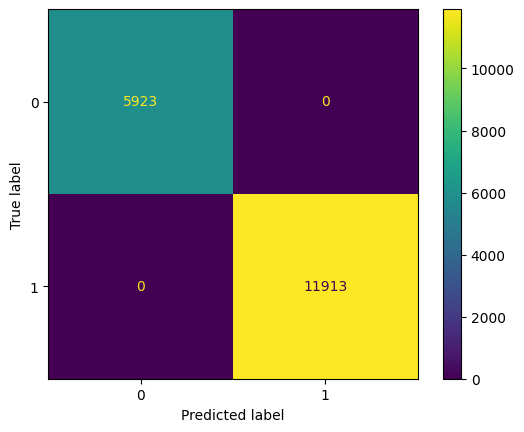

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#fit the model
rf_tuned.fit(X_train, y_train)

#make predictions
y_pred_train = rf_tuned.predict(X_train)

#classification report
print(classification_report(y_train, y_pred_train))

#confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Checking model performance on validation set

In [ ]:
def model_performance_classification_sklearn(model, X, y):
    """
    Function to compute classification metrics.
    """
    # predicting on the data
    y_pred = model.predict(X)

    # computing the metrics
    accuracy = accuracy_score(y, y_pred)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": accuracy,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

rf_tuned_model_train_perf = model_performance_classification_sklearn(rf_tuned, X_train, y_train)
print("Training performance of the tuned Random Forest model:")
print(rf_tuned_model_train_perf)

rf_tuned_model_test_perf = model_performance_classification_sklearn(rf_tuned, X_test, y_test)
print("\nTesting performance of the tuned Random Forest model:")
print(rf_tuned_model_test_perf)

Training performance of the tuned Random Forest model:
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

Testing performance of the tuned Random Forest model:
   Accuracy    Recall  Precision        F1
0  0.719388  0.836043   0.765423  0.799176


##Hyperparameter Tuning - AdaBoost Classifier


In [ ]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for base_estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": np.arange(0.01,0.1,0.05),
}

# Type of scoring used to compare parameter  combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(abc_tuned, parameters, scoring=acc_scorer, cv=3)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

CPU times: user 1min 6s, sys: 209 ms, total: 1min 6s
Wall time: 1min 17s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=np.float64(0.060000000000000005),
                   n_estimators=np.int64(100), random_state=1)

Checking model performance on training set

              precision    recall  f1-score   support

           0       0.67      0.50      0.57      5923
           1       0.78      0.87      0.82     11913

    accuracy                           0.75     17836
   macro avg       0.72      0.69      0.70     17836
weighted avg       0.74      0.75      0.74     17836



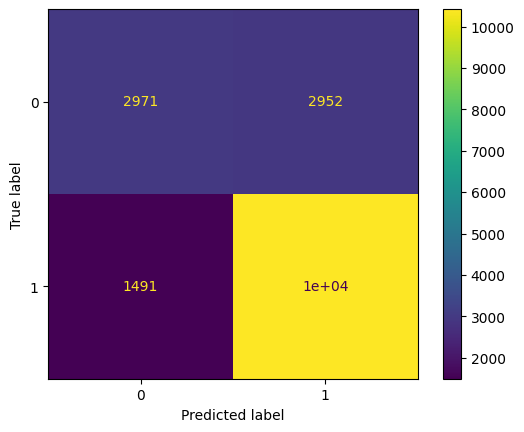

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#make predictions
y_pred_train = abc_tuned.predict(X_train)

#classification report
print(classification_report(y_train, y_pred_train))

#confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Checking model performance on validation set

In [ ]:
abc_tuned_model_val_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.742805,0.87287,0.771869,0.819268


##Hyperparameter Tuning - Gradient Boosting Classifier

In [ ]:
%%time
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [50],
    "subsample": [0.7],
    "max_features": [0.7],
    "learning_rate": [0.1],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=acc_scorer, cv=3)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

CPU times: user 6.93 s, sys: 24.5 ms, total: 6.95 s
Wall time: 9.09 s


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.7, n_estimators=50, random_state=1,
                           subsample=0.7)

Checking model performance on training set

              precision    recall  f1-score   support

           0       0.68      0.50      0.57      5923
           1       0.78      0.88      0.83     11913

    accuracy                           0.76     17836
   macro avg       0.73      0.69      0.70     17836
weighted avg       0.75      0.76      0.74     17836



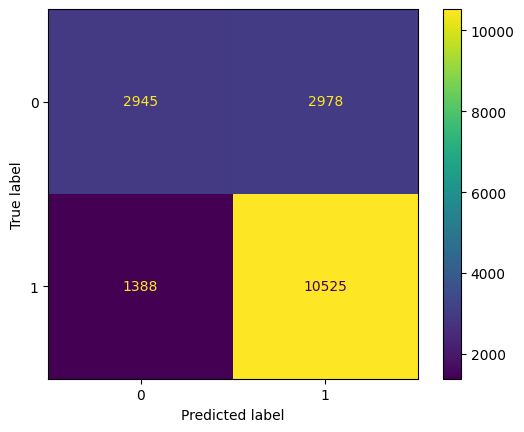

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#make predictions
y_pred_train = gbc_tuned.predict(X_train)

#classification report
print(classification_report(y_train, y_pred_train))

#confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Checking model performance on validation set

In [ ]:
confusion_matrix(y_test, gbc_tuned.predict(X_test))


array([[1204, 1335],
       [ 612, 4493]])

## Hyperparameter Tuning - XGBoost Classifier

In [ ]:
%%time
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "scale_pos_weight": [1,2,5],
    "subsample": [0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
    "gamma": [1,3]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=acc_scorer, cv=3)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

CPU times: user 2min 47s, sys: 1.15 s, total: 2min 49s
Wall time: 1min 39s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, ...)

Checking model performance on training set

              precision    recall  f1-score   support

           0       0.89      0.36      0.51      5923
           1       0.75      0.98      0.85     11913

    accuracy                           0.77     17836
   macro avg       0.82      0.67      0.68     17836
weighted avg       0.80      0.77      0.74     17836



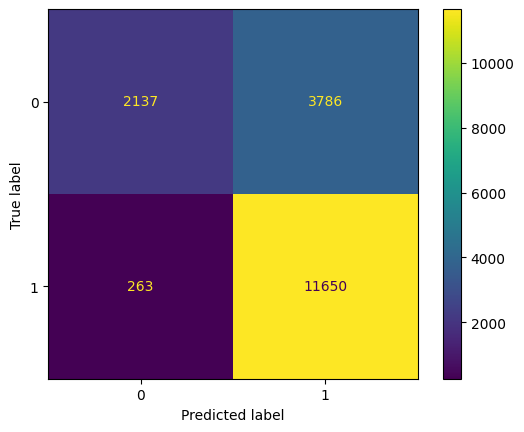

Training performance of the tuned XGBoost model:
   Accuracy    Recall  Precision        F1
0  0.772987  0.977923   0.754729  0.851951


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#make predictions
y_pred_train = xgb_tuned.predict(X_train)

#classification report
print(classification_report(y_train, y_pred_train))

#confusion matrix
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
print("Training performance of the tuned XGBoost model:")
print(xgb_tuned_model_train_perf)

Checking model performance on validation set

In [ ]:
confusion_matrix(y_test, xgb_tuned.predict(X_test))
xgb_tuned_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
print("\nTesting performance of the tuned XGBoost model:")
print(xgb_tuned_model_test_perf)


Testing performance of the tuned XGBoost model:
   Accuracy    Recall  Precision        F1
0  0.721219  0.943193   0.723407  0.818808


# **Model Comparison and Final Model Selection**

In [ ]:
#training performance comparison

abc_tuned_model_train_perf = model_performance_classification_sklearn(abc_tuned, X_train, y_train)
gbc_tuned_model_train_perf = model_performance_classification_sklearn(gbc_tuned, X_train, y_train)


model_train_comp_df = pd.concat(
    [
        rf_tuned_model_train_perf,
        abc_tuned_model_train_perf,
        gbc_tuned_model_train_perf,
        xgb_tuned_model_train_perf,
    ],
    axis=0,
).T

model_train_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned AdaBoost",
    "Tuned Gradient Boosting",
    "XGBoost Classifier Tuned",
]
print("Training performance comparison:")
model_train_comp_df

Training performance comparison:


,Tuned Random Forest,Tuned AdaBoost,Tuned Gradient Boosting,XGBoost Classifier Tuned
Accuracy,1.0,0.750897,0.755214,0.772987
Recall,1.0,0.874843,0.883489,0.977923
Precision,1.0,0.779273,0.779456,0.754729
F1,1.0,0.824297,0.828218,0.851951


In [ ]:
#compare validation performance of the models
abc_tuned_model_test_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
gbc_tuned_model_test_perf = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)

model_test_comp_df = pd.concat(
    [
        rf_tuned_model_test_perf,
        abc_tuned_model_test_perf,
        gbc_tuned_model_test_perf,
        xgb_tuned_model_test_perf,
    ],
    axis=0,
).T

model_test_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned AdaBoost",
    "Tuned Gradient Boosting",
    "XGBoost Classifier Tuned",
]
print("Testing performance comparison:")
model_test_comp_df

Testing performance comparison:


,Tuned Random Forest,Tuned AdaBoost,Tuned Gradient Boosting,XGBoost Classifier Tuned
Accuracy,0.719388,0.742805,0.745290,0.721219
Recall,0.836043,0.872870,0.880118,0.943193
Precision,0.765423,0.771869,0.770933,0.723407
F1,0.799176,0.819268,0.821915,0.818808


In [ ]:
#check performance on test set
rf_tuned_model_test_perf = model_performance_classification_sklearn(rf_tuned, X_test, y_test)
abc_tuned_model_test_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
gbc_tuned_model_test_perf = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)
xgb_tuned_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
print("Testing performance of the tuned Random Forest model:")
print(rf_tuned_model_test_perf)
print("\nTesting performance of the tuned AdaBoost model:")
print(abc_tuned_model_test_perf)
print("\nTesting performance of the tuned Gradient Boosting model:")
print(gbc_tuned_model_test_perf)
print("\nTesting performance of the tuned XGBoost model:")
print(xgb_tuned_model_test_perf)

Testing performance of the tuned Random Forest model:
   Accuracy    Recall  Precision        F1
0  0.719388  0.836043   0.765423  0.799176

Testing performance of the tuned AdaBoost model:
   Accuracy   Recall  Precision        F1
0  0.742805  0.87287   0.771869  0.819268

Testing performance of the tuned Gradient Boosting model:
   Accuracy    Recall  Precision        F1
0   0.74529  0.880118   0.770933  0.821915

Testing performance of the tuned XGBoost model:
   Accuracy    Recall  Precision        F1
0  0.721219  0.943193   0.723407  0.818808


## Final Model Selection: **Gradient Boosting Model**

## Important features of the final model

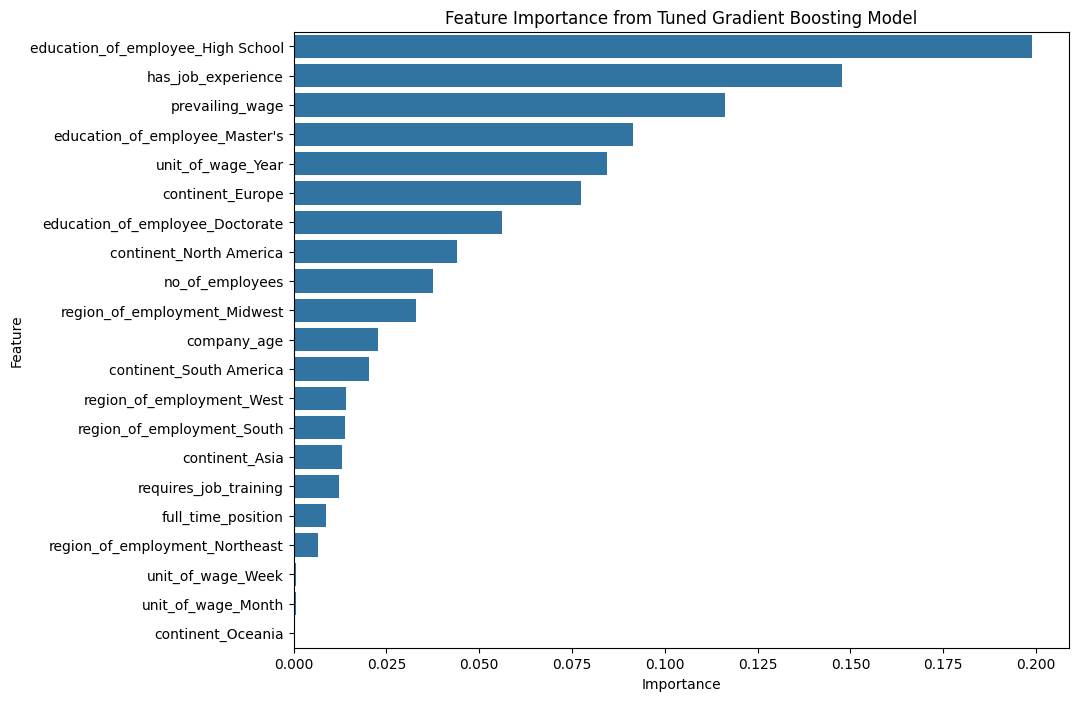

Top 10 most important features:
                              Feature  Importance
11  education_of_employee_High School    0.198821
0                  has_job_experience    0.147873
3                     prevailing_wage    0.116252
12     education_of_employee_Master's    0.091314
19                  unit_of_wage_Year    0.084540
6                    continent_Europe    0.077439
10    education_of_employee_Doctorate    0.056095
7             continent_North America    0.044121
2                     no_of_employees    0.037650
13       region_of_employment_Midwest    0.033018


In [ ]:
# Get the best estimator from the grid search
best_gb_model = gbc_tuned

# Get feature importances from the best model
feature_importances = best_gb_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Tuned Gradient Boosting Model')
plt.show()

# Display the top 10 most important features
print("Top 10 most important features:")
print(feature_importance_df.head(10))

# **Actionable Insights and Recommendations**

### Actionable Insights and Recommendations

Based on the feature importance analysis of the tuned Gradient Boosting model, we can derive the following actionable insights and recommendations:

**Key Drivers of Visa Approval:**

1.  **Prevailing Wage:** This is the most influential factor. Higher prevailing wages are strongly associated with a higher likelihood of visa certification.
2.  **Company Age:** Older, more established companies tend to have higher visa approval rates. This could be due to their stability and proven track record.
3.  **Number of Employees:** Larger companies, in terms of the number of employees, have a slightly higher chance of getting visa applications approved.
4.  **Education Level:** A Master's degree is a significant positive factor for visa approval.
5.  **Job Experience:** Having prior job experience is a crucial factor for visa certification.

**Recommendations for Applicants:**

*   **Target Higher-Paying Jobs:** Applicants should focus on securing job offers with salaries that are competitive and at or above the prevailing wage for their occupation and region.
*   **Target Established Companies:** Applying to older, more established companies can increase the chances of visa approval.
*   **Highlight Educational Qualifications:** Applicants with Master's degrees should prominently feature their educational background in their applications.
*   **Emphasize Job Experience:** Highlighting relevant job experience is critical. Applicants should ensure their resumes and application materials clearly demonstrate their experience.
*   **Consider Employment Region:** The "Midwest" region shows the highest approval rates. While not always feasible to change, this is a factor to consider.

**Recommendations for "EasyVisa" Firm:**

*   **Prioritize Applications:** EasyVisa can prioritize applications based on the key drivers identified. For example, applications with high prevailing wages, from established companies, and for applicants with Master's degrees and job experience can be fast-tracked.
*   **Develop Applicant Profiles:** Create profiles of ideal candidates based on these factors to help screen and advise potential applicants. This can help manage the increasing volume of applications more effectively.
*   **Data-Driven Counseling:** Use these insights to provide data-driven advice to applicants on how to strengthen their visa application profiles.